<a href="https://colab.research.google.com/github/salonisngh/DEEP_LEARNING/blob/main/time_series_forecasting_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

roll_no = "102317246"

digits = [int(d) for d in roll_no]

window_size = sum(digits) % 10 + 8
prediction_horizon = int(roll_no[-2:]) % 3 + 1
hidden_size = int(roll_no[:3]) % 16 + 8

print("Window:", window_size)
print("Horizon:", prediction_horizon)
print("Hidden:", hidden_size)

Window: 14
Horizon: 2
Hidden: 14


In [24]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler # Ensure MinMaxScaler is imported
import os # Import os for path checking

file_path = '/kaggle/input/datasets/kandij/electric-production/Electric_Production.csv'

# To resolve the FileNotFoundError, the dataset needs to be made available in the Colab environment.
# Check if the file exists at the initial path. If not, try to download and use it.
if not os.path.exists(file_path):
    print("Dataset not found at original path. Attempting to download from Kaggle...")
    # These commands assume you have already uploaded your kaggle.json to /content/
    # and have run `!pip install kaggle` in a previous cell.
    # !mkdir -p ~/.kaggle
    # !cp /content/kaggle.json ~/.kaggle/
    # !chmod 600 ~/.kaggle/kaggle.json

    # Download and unzip the dataset to the current directory
    !kaggle datasets download -d kandij/electric-production -p .
    !unzip -o electric-production.zip

    # Update file_path to the location of the downloaded CSV
    file_path = 'Electric_Production.csv' # Assuming the file is extracted to the current directory
    print(f"File path updated to: {file_path}")

df = pd.read_csv(file_path, parse_dates=['DATE'], index_col='DATE')

scaler = MinMaxScaler((0,1))
scaled_data = scaler.fit_transform(df.values)

data = scaled_data

Dataset not found at original path. Attempting to download from Kaggle...
Dataset URL: https://www.kaggle.com/datasets/kandij/electric-production
License(s): unknown
electric-production.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  electric-production.zip
  inflating: Electric_Production.csv  
File path updated to: Electric_Production.csv


In [25]:
def create_windows(data, window_size, horizon):
    X, y = [], []
    for i in range(len(data) - window_size - horizon + 1):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size:i+window_size+horizon])
    return np.array(X), np.array(y)

X, y = create_windows(data, window_size, prediction_horizon)

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).squeeze(-1)

# chronological split
train_size = int(0.8 * len(X))

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [26]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(window_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, prediction_horizon)
        )

    def forward(self, x):
        x = x.squeeze(-1)
        return self.net(x)

In [27]:
class CustomRNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden_size = hidden_size
        self.Wxh = nn.Linear(1, hidden_size)
        self.Whh = nn.Linear(hidden_size, hidden_size)
        self.fc = nn.Linear(hidden_size, prediction_horizon)

    def forward(self, x):
        batch_size, seq_len, _ = x.size()
        h = torch.zeros(batch_size, self.hidden_size).to(device)

        for t in range(seq_len):
            h = torch.tanh(self.Wxh(x[:, t, :]) + self.Whh(h))

        return self.fc(h)

In [28]:
class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(1, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, prediction_horizon)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

In [29]:
class TransformerModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Linear(1, hidden_size)
        encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_size, nhead=2)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.fc = nn.Linear(hidden_size, prediction_horizon)

    def forward(self, x):
        x = self.embedding(x)
        x = x.permute(1, 0, 2)
        out = self.transformer(x)
        out = out[-1]
        return self.fc(out)

In [30]:
def train_model(model, epochs=10):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()

    losses = []

    for epoch in range(epochs):
        model.train()

        optimizer.zero_grad()
        out = model(X_train.to(device))
        loss = loss_fn(out, y_train.to(device))
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

    return losses

In [31]:
def evaluate(model):
    model.eval()
    preds = model(X_test.to(device)).detach().cpu().numpy()
    true = y_test.numpy()

    mse = mean_squared_error(true, preds)
    mae = mean_absolute_error(true, preds)
    rmse = np.sqrt(mse)

    print("MSE:", mse)
    print("MAE:", mae)
    print("RMSE:", rmse)

    return preds, true

In [32]:
def plot_results(losses, preds, true):
    plt.figure()
    plt.plot(losses)
    plt.title("Training Loss")

    plt.figure()
    plt.plot(true.flatten(), label="Actual")
    plt.plot(preds.flatten(), label="Predicted")
    plt.legend()


===== MLP =====
Epoch 1, Loss: 0.2059
Epoch 2, Loss: 0.1972
Epoch 3, Loss: 0.1888
Epoch 4, Loss: 0.1807
Epoch 5, Loss: 0.1729
Epoch 6, Loss: 0.1654
Epoch 7, Loss: 0.1582
Epoch 8, Loss: 0.1512
Epoch 9, Loss: 0.1446
Epoch 10, Loss: 0.1382
MSE: 0.2971017360687256
MAE: 0.529545783996582
RMSE: 0.5450703955166943


/tmp/ipykernel_22220/1167397339.py:6: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)



===== RNN =====
Epoch 1, Loss: 0.3295
Epoch 2, Loss: 0.3087
Epoch 3, Loss: 0.2886
Epoch 4, Loss: 0.2691
Epoch 5, Loss: 0.2502
Epoch 6, Loss: 0.2320
Epoch 7, Loss: 0.2145
Epoch 8, Loss: 0.1977
Epoch 9, Loss: 0.1817
Epoch 10, Loss: 0.1664
MSE: 0.22632209956645966
MAE: 0.4032507538795471
RMSE: 0.47573322310561794

===== LSTM =====
Epoch 1, Loss: 0.4971
Epoch 2, Loss: 0.4908
Epoch 3, Loss: 0.4846
Epoch 4, Loss: 0.4785
Epoch 5, Loss: 0.4725
Epoch 6, Loss: 0.4665
Epoch 7, Loss: 0.4606
Epoch 8, Loss: 0.4548
Epoch 9, Loss: 0.4490
Epoch 10, Loss: 0.4432
MSE: 0.7314670085906982
MAE: 0.8448503017425537
RMSE: 0.8552584454951019

===== Transformer =====
Epoch 1, Loss: 0.8024
Epoch 2, Loss: 0.3368
Epoch 3, Loss: 0.1920
Epoch 4, Loss: 0.0835
Epoch 5, Loss: 0.0506
Epoch 6, Loss: 0.0591
Epoch 7, Loss: 0.0727
Epoch 8, Loss: 0.0753
Epoch 9, Loss: 0.0670
Epoch 10, Loss: 0.0534
MSE: 0.05089181661605835
MAE: 0.18763376772403717
RMSE: 0.2255921466187561


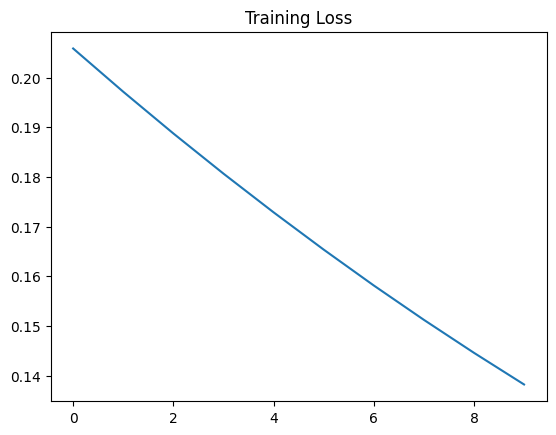

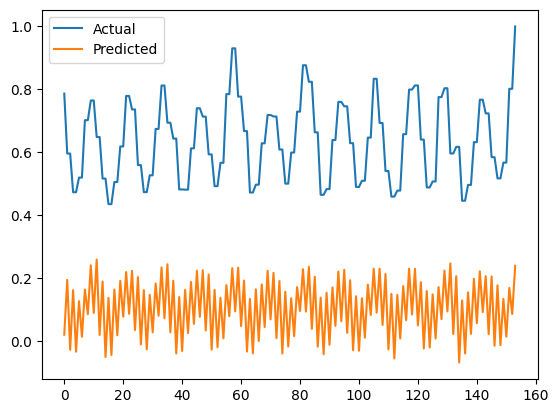

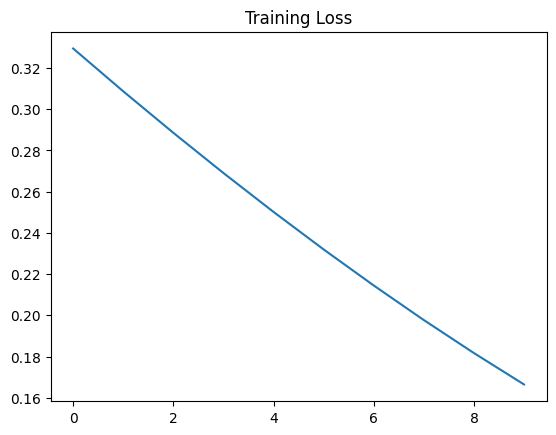

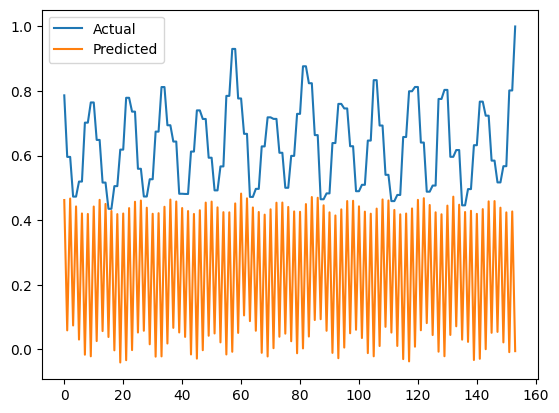

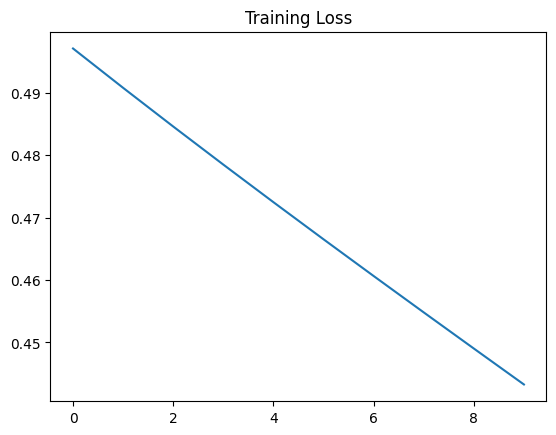

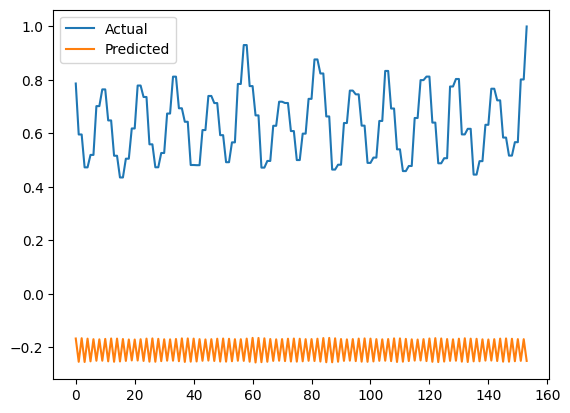

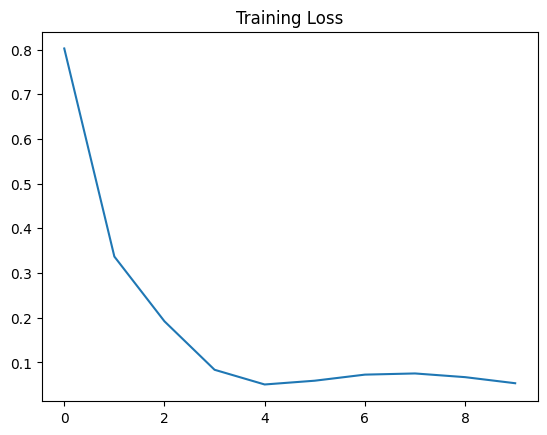

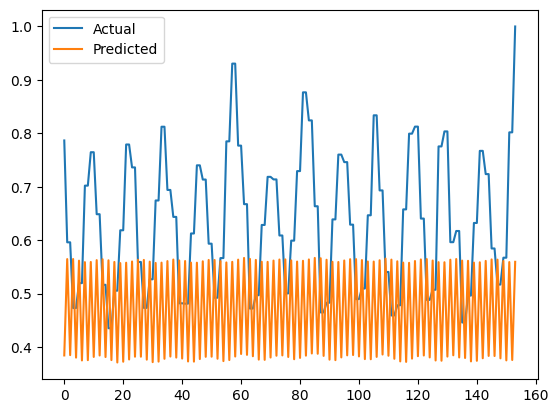

In [33]:
models = {
    "MLP": MLP(),
    "RNN": CustomRNN(),
    "LSTM": LSTMModel(),
    "Transformer": TransformerModel()
}

results = {}

for name, model in models.items():
    print(f"\n===== {name} =====")
    losses = train_model(model)
    preds, true = evaluate(model)
    plot_results(losses, preds, true)
    results[name] = (preds, true)

In [34]:
for factor in [0.5, 2]:
    new_window = int(window_size * factor)

    print(f"\nAblation window: {new_window}")

    X_new, y_new = create_windows(data, new_window, prediction_horizon)

    # repeat training (you can reuse same pipeline)


Ablation window: 7

Ablation window: 28
